# Case Study Selection Case Study Selection

Telivision market and price analysis in Flipcart.

# Problem Statement🧠

The objective of this project is to analyze the pricing patterns of Telivision listed on Flipkart and understand the relationship between various Telivision specifications and their prices. By scraping Telivision data from Flipkart using Python, BeautifulSoup, and Regular Expressions, this project aims to extract useful insights through data cleaning, exploratory data analysis, and visualization.


### Extracting the Data 🎯

#! pip install requests

In [52]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [53]:
url="https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_OrganicAutoSuggest_5_3_na_na_ps&otracker1=AS_QueryStore_OrganicAutoSuggest_5_3_na_na_ps&as-pos=5&as-type=HISTORY&suggestionId=television%7CTelevisions&requestId=68bda1f9-0a16-4c68-986f-497a9dc43274"
url

'https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_OrganicAutoSuggest_5_3_na_na_ps&otracker1=AS_QueryStore_OrganicAutoSuggest_5_3_na_na_ps&as-pos=5&as-type=HISTORY&suggestionId=television%7CTelevisions&requestId=68bda1f9-0a16-4c68-986f-497a9dc43274'

In [54]:
import requests

In [55]:
page= requests.get(url)
page

<Response [200]>

In [56]:
page.text

'<!doctype html><html lang="en"><head><link href="https://rukminim2.flixcart.com" rel="preconnect"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.aa1465.css"/><link rel="stylesheet" href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.fbaef9.css"/><meta http-equiv="Content-type" content="text/html; charset=utf-8"/><meta http-equiv="X-UA-Compatible" content="IE=Edge"/><meta property="fb:page_id" content="102988293558"/><meta property="fb:admins" content="658873552,624500995,100000233612389"/><link rel="shortcut icon" href="https://static-assets-web.flixcart.com/www/promos/new/20150528-140547-favicon-retina.ico"/><link type="application/opensearchdescription+xml" rel="search" href="/osdd.xml?v=2"/><meta property="og:type" content="website"/><meta name="og_site_name" property="og:site_name" content="Flipkart.com"/><link rel="apple-touch-icon" sizes="57x57" href="/apple-touch-icon-57x57.png"/><link rel="apple

In [57]:
from bs4 import BeautifulSoup

In [58]:
soup = BeautifulSoup(page.text)
soup

<!DOCTYPE html>
<html lang="en"><head><link href="https://rukminim2.flixcart.com" rel="preconnect"/><link href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.aa1465.css" rel="stylesheet"/><link href="//static-assets-web.flixcart.com/fk-p-linchpin-web/fk-cp-zion/css/bundle.fbaef9.css" rel="stylesheet"/><meta content="text/html; charset=utf-8" http-equiv="Content-type"/><meta content="IE=Edge" http-equiv="X-UA-Compatible"/><meta content="102988293558" property="fb:page_id"/><meta content="658873552,624500995,100000233612389" property="fb:admins"/><link href="https://static-assets-web.flixcart.com/www/promos/new/20150528-140547-favicon-retina.ico" rel="shortcut icon"/><link href="/osdd.xml?v=2" rel="search" type="application/opensearchdescription+xml"/><meta content="website" property="og:type"/><meta content="Flipkart.com" name="og_site_name" property="og:site_name"/><link href="/apple-touch-icon-57x57.png" rel="apple-touch-icon" sizes="57x57"/><link href="/app

In [59]:
soup.find("div",class_='RG5Slk').text

'Coocaa Y74 Plus 138 cm (55 inch) Ultra HD (4K) LED Smart Google TV 2025 Edition with Dolby Audio | 32 ...'

In [60]:
soup.find_all("div",class_='RG5Slk')

[<div class="RG5Slk">Coocaa Y74 Plus 138 cm (55 inch) Ultra HD (4K) LED Smart Google TV 2025 Edition with Dolby Audio | 32 ...</div>,
 <div class="RG5Slk">PHILIPS 108 cm (43 inch) QLED Ultra HD (4K) Smart Google TV 2025 Edition with Dolby Vision |30W Dolby ...</div>,
 <div class="RG5Slk">Foxsky 60 cm (24 inch) HD Ready LED Smart Android TV 2025 Edition</div>,
 <div class="RG5Slk">LG LR570 80 cm (32 inch) HD Ready LED Smart WebOS TV 2025 Edition with Alpha5 Gen 6 AI Processor 125+ ...</div>,
 <div class="RG5Slk">PHILIPS 164 cm (65 inch) Ultra HD (4K) Mini LED Smart Google TV 2025 Edition with Local Dimming Dolby ...</div>,
 <div class="RG5Slk">Reliance 80 cm (32 inch) HD Ready LED Smart Android TV 2025 Edition with Cloud Base TV</div>,
 <div class="RG5Slk">realme TechLife 80 cm (32 inch) QLED HD Ready Smart Google TV 2025 Edition</div>,
 <div class="RG5Slk">Foxsky 60 cm (24 inch) HD Ready LED TV</div>,
 <div class="RG5Slk">LG AI TV UA8200 108 cm (43 inch) Ultra HD (4K) LED Smart WebOS T

In [61]:
title = []

for i in soup.find_all("div",class_='RG5Slk'):
    text = i.text 
    regex=text.split()[0]     
    if regex:
        title.append(regex.strip())
    else:
        title.append(np.nan)
      
        


In [62]:
import re
inches= []
for i in soup.find_all("div",class_='RG5Slk'):
    text = i.text
    regex = re.findall(r"\s\((\d+)\sinch\)",text)    #\s\((\d+\s\w+)\)*
    if regex:
        inches.append(regex[0].strip())   # \s*\d+\scm
    else:
        inches.append(np.nan)


In [63]:
len(inches)

24

In [64]:
screen_size_in_cm = []
for i in soup.find_all("div",class_='RG5Slk'):
    text = i.text
    regex = re.findall(r"\s(\d+|\d+.\d)\scm",text,re.I) #\s*\d+\scm|\s*\d+.\d\scm
    if regex:
        screen_size_in_cm.append(regex[0].strip())
    else:
        screen_size_in_cm.append(np.nan)

In [65]:
len(screen_size_in_cm)

24

In [66]:

year=[]
for i in soup.find_all("div",class_='col col-7-12'):   
    text=i.find("ul",class_='HwRTzP')
    regex = re.findall(r"Year:\s(.+)Total",text.text,re.I) 
    if regex:
        year.append(regex[0].strip())
    else:
        year.append(np.nan)

    
      
    

In [67]:
len(year)

24

In [68]:
sound_output_in_WT=[]
for i in soup.find_all("div",class_='col col-7-12'):
    text=i.find("ul",class_='HwRTzP')
    regex = re.findall(r"Output:\s(\d+)\s\w",text.text,re.I) 
    if regex:
        sound_output_in_WT.append(regex[0].strip())
    else:
        sound_output_in_WT.append(np.nan)

In [69]:
len(sound_output_in_WT)

24

In [70]:
tv=[]
for i in soup.find_all("div",class_='col col-7-12'):
    text=i.find("ul",class_='HwRTzP')
    regex = re.findall(r"\|\s(.+)Model",text.text,re.I) 
    if regex:
        tv.append(regex[0].strip())
    else:
        tv.append(np.nan)

In [71]:
len(tv)

24

In [72]:
rating = []
for i in soup.find_all("div",class_='col col-7-12'):
    text=i.find("div",class_='MKiFS6')
    if text:
        rating.append(text.text)
    else:
        rating.append(np.nan)

In [73]:
len(rating)

24

In [74]:
order_id=[]
for i in soup.find_all("div",class_='col col-7-12'):
    text=i.find("ul",class_='HwRTzP')
    regex = re.findall(r"ID:\s(.+)Launch",text.text,re.I) 
    if regex:
        order_id.append(regex[0].strip())
    else:
        order_id.append(np.nan)

In [75]:
len(order_id)

24

In [76]:
price = []
for i in soup.find_all("div",class_='col col-5-12 mao5dl'):
         text = i.text 
         regex = re.findall(r"₹(\d+,\d+)₹",text)
         if regex:
              price.append(regex[0].replace(",",''))   #(.+)(?:\s\(4K\)|\s\|)
         else:
              price.append(np.nan)
    

In [77]:
quality=[]
for i in soup.find_all("div",class_='col col-7-12'):
    text=i.find("ul",class_='HwRTzP')
    regex = re.findall(r"(.+)(?:\s\(4K\)|\s\|\sQLED|\s\|\sLED)",text.text,re.I) 
    if regex:
        quality.append(regex[0].strip())
    else:
        quality.append(np.nan)

In [78]:
len(quality)

24

In [79]:
dic = {"Title":title,"Inches":inches,"Screen_size_in_cm":screen_size_in_cm,"Year":year,"Sound_output_in_WT":sound_output_in_WT,"TV":tv,"Rating":rating,"ID":order_id,
       "Price":price,"Quality":quality}
dic

{'Title': ['Coocaa',
  'PHILIPS',
  'Foxsky',
  'LG',
  'PHILIPS',
  'Reliance',
  'realme',
  'Foxsky',
  'LG',
  'Coocaa',
  'PHILIPS',
  'Reliance',
  'iFFALCON',
  'XIAOMI',
  'TCL',
  'PHILIPS',
  'Reliance',
  'Reliance',
  'BESTON',
  'XIAOMI',
  'Reliance',
  'Reliance',
  'Thomson',
  'Samsung'],
 'Inches': ['55',
  '43',
  '24',
  '32',
  '65',
  '32',
  '32',
  '24',
  '43',
  '50',
  '55',
  '43',
  '55',
  '50',
  '55',
  '32',
  '32',
  '32',
  '32',
  '32',
  '55',
  '32',
  '32',
  '32'],
 'Screen_size_in_cm': ['138',
  '108',
  '60',
  '80',
  '164',
  '80',
  '80',
  '60',
  '108',
  '126',
  '138',
  '109',
  '138',
  '125',
  '139',
  '80',
  '81',
  '80',
  '80',
  '80',
  '139',
  '80',
  '80',
  '80'],
 'Year': ['2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2023',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025',
  '2025'],
 'Sound_output_i

In [80]:
import pandas as pd

In [81]:
single_page_df = pd.DataFrame(dic)
single_page_df

,Title,Inches,Screen_size_in_cm,Year,Sound_output_in_WT,TV,Rating,ID,Price,Quality
0,Coocaa,55,138,2025,20,LED,4,55Y74 Plus,21499,Ultra HD (4K)
1,PHILIPS,43,108,2025,30,QLED,4,43PQT8100/94,22999,Ultra HD (4K)
2,Foxsky,24,60,2025,30,LED,4.1,24 FSELS PRO,5799,HD Ready
3,LG,32,80,2025,10,LED,4.4,32LR570B6LA,13490,HD Ready
4,PHILIPS,65,164,2025,36,Mini LED,4.2,65MLED610/94,55999,Ultra HD
5,Reliance,32,80,2025,20,LED,3.9,RW32MP4656HD,8999,HD Ready
6,realme,32,80,2025,26,QLED,4.3,32HDGQRDDAQ,10299,HD Ready
7,Foxsky,24,60,2023,30,LED,4,24FSN,5299,HD Ready
8,LG,43,108,2025,20,LED,4.4,43UA82006LA,28990,Ultra HD (4K)
9,Coocaa,50,126,2025,20,LED,4.1,50S4U Plus,16999,Full HD


In [82]:
single_page_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 24 entries, 0 to 23
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Title               24 non-null     object
 1   Inches              24 non-null     object
 2   Screen_size_in_cm   24 non-null     object
 3   Year                24 non-null     object
 4   Sound_output_in_WT  24 non-null     object
 5   TV                  24 non-null     object
 6   Rating              23 non-null     object
 7   ID                  24 non-null     object
 8   Price               24 non-null     object
 9   Quality             24 non-null     object
dtypes: object(10)
memory usage: 2.0+ KB


In [83]:
title_m = []
inches_m = []
screen_size_in_cm_m = []
year_m = []
sound_output_in_WT_m = []
tv_m = []
rating_m=[]
order_id_m = []
price_m =[]
quality_m=[]

for i in range(1,25):
    url_m = f"https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&otracker1=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&as-pos=1&as-type=HISTORY&suggestionId=television%7CTelevisions&requestId=8bce22de-730f-4ba8-821c-08604ddab2c9&as-searchtext=tel={i}"
    print(url_m)
    page_m = requests.get(url,headers = {'User-Agent':'Mozilla/5.0 (Windows NT 10.0; Win64; x64)' })    
    print("*"*100)
    soup_m = BeautifulSoup(page_m.text)
    
    for j in soup_m.find_all("div",class_='RG5Slk'):
        text = j.text         
        regex=text.split()[0]             
        if regex:
            title_m.append(regex.strip())
        else:
            title_m.append(np.nan)
            
    for j in soup_m.find_all("div",class_='RG5Slk'):
        text = j.text
        regex = re.findall(r"\s\((\d+)\sinch\)",text) 
        if regex:
            inches_m.append(regex[0].strip())
        else:
            inches_m.append(np.nan)
            
    for j in soup_m.find_all("div",class_='RG5Slk'):
        text = j.text
        regex = re.findall(r"\s(\d+|\d+.\d)\scm",text,re.I) #\s*\d+\scm|\s*\d+.\d\scm
        if regex:
            screen_size_in_cm_m.append(regex[0].strip())
        else:
            screen_size_in_cm_m.append(np.nan)
             
    for j in soup_m.find_all("div",class_='col col-7-12'):
         text=j.find("ul",class_='HwRTzP')
         regex = re.findall(r"Year:\s(.+)Total",text.text,re.I) 
         if regex:
             year_m.append(regex[0].strip())
         else:
             year_m.append(np.nan)
             
    for j in soup_m.find_all("div",class_='col col-7-12'):
         text=j.find("ul",class_='HwRTzP')
         regex = re.findall(r"Output:\s(\d+)\s\w",text.text,re.I) 
         if regex:
             sound_output_in_WT_m.append(regex[0].strip())
         else:
             sound_output_in_WT_m.append(np.nan) 

    for j in soup_m.find_all("div",class_='col col-7-12'):
         text=j.find("ul",class_='HwRTzP')
         regex = re.findall(r"\|\s(.+)Model",text.text,re.I) 
         if regex:
             tv_m.append(regex[0].strip())
         else:
             tv_m.append(np.nan)

    
    for j in soup.find_all("div",class_='col col-7-12'):
         text=j.find("div",class_='MKiFS6')
         if text:
             rating_m.append(text.text)
         else:
             rating_m.append(np.nan)         
             
    for j in soup_m.find_all("div",class_='col col-7-12'):
         text=j.find("ul",class_='HwRTzP')
         regex = re.findall(r"ID:\s(.+)Launch",text.text,re.I) 
         if regex:
             order_id_m.append(regex[0].strip())
         else:
             order_id_m.append(np.nan)

    
    for j in soup_m.find_all("div",class_='col col-5-12 mao5dl'):
         text = j.text 
         regex = re.findall(r"₹(\d+,\d+)₹",text)
         if regex:
              price_m.append(regex[0].replace(",",''))
         else:
              price_m.append(np.nan)
             
    for j in soup_m.find_all("div",class_='col col-7-12'):
          text=j.find("ul",class_='HwRTzP')
          regex = re.findall(r"(.+)(?:\s\(4K\)|\s\|\sQLED|\s\|\sLED)",text.text,re.I) 
          if regex:
              quality_m.append(regex[0].strip())
          else:
              quality_m.append(np.nan)
        


https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&otracker1=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&as-pos=1&as-type=HISTORY&suggestionId=television%7CTelevisions&requestId=8bce22de-730f-4ba8-821c-08604ddab2c9&as-searchtext=tel=1
****************************************************************************************************
https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&otracker1=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&as-pos=1&as-type=HISTORY&suggestionId=television%7CTelevisions&requestId=8bce22de-730f-4ba8-821c-08604ddab2c9&as-searchtext=tel=2
****************************************************************************************************
https://www.flipkart.com/search?q=television&sid=ckf%2Cczl&as=on&as-show=on&otracker=AS_QueryStore_HistoryAutoSuggest_1_3_na_na_na&otracker1=AS_QueryStore_HistoryAu

In [89]:
print(len(title_m ))

576


In [90]:
print(len(inches_m))

576


In [91]:
print(len(screen_size_in_cm_m)) 

576


In [92]:
print(len(year_m)) 

576


In [93]:
print(len(sound_output_in_WT_m))

576


In [94]:
print(len(tv_m))

576


In [95]:
print(len(order_id_m))

576


In [96]:
print(len(price_m))

576


In [97]:
print(len(quality_m))

576


In [98]:
dic_m = {"Title":title_m,"Inches":inches_m,"Screen_size_in_cm":screen_size_in_cm_m,"Year":year_m,"Sound_output_in_WT":sound_output_in_WT_m,"TV":tv_m,"Rating":rating_m,"ID":order_id_m,
       "Price":price_m,"Quality":quality_m} 
dic_m

{'Title': ['Coocaa',
  'PHILIPS',
  'Foxsky',
  'LG',
  'PHILIPS',
  'Reliance',
  'realme',
  'Foxsky',
  'LG',
  'Coocaa',
  'PHILIPS',
  'Reliance',
  'iFFALCON',
  'XIAOMI',
  'TCL',
  'PHILIPS',
  'Reliance',
  'Reliance',
  'BESTON',
  'XIAOMI',
  'Reliance',
  'Reliance',
  'Thomson',
  'Samsung',
  'Coocaa',
  'PHILIPS',
  'Foxsky',
  'LG',
  'PHILIPS',
  'Reliance',
  'realme',
  'Foxsky',
  'LG',
  'Coocaa',
  'PHILIPS',
  'Reliance',
  'iFFALCON',
  'XIAOMI',
  'TCL',
  'PHILIPS',
  'Reliance',
  'Reliance',
  'BESTON',
  'XIAOMI',
  'Reliance',
  'Reliance',
  'Thomson',
  'Samsung',
  'Coocaa',
  'PHILIPS',
  'Foxsky',
  'LG',
  'PHILIPS',
  'Reliance',
  'realme',
  'Foxsky',
  'LG',
  'Coocaa',
  'PHILIPS',
  'Reliance',
  'iFFALCON',
  'XIAOMI',
  'TCL',
  'PHILIPS',
  'Reliance',
  'Reliance',
  'BESTON',
  'XIAOMI',
  'Reliance',
  'Reliance',
  'Thomson',
  'Samsung',
  'Coocaa',
  'PHILIPS',
  'Foxsky',
  'LG',
  'PHILIPS',
  'Reliance',
  'realme',
  'Foxsky',
  'L

# Importing DataFrame

In [124]:
import pandas as pd
df_m = pd.DataFrame(dic_m)
df_m

,Title,Inches,Screen_size_in_cm,Year,Sound_output_in_WT,TV,Rating,ID,Price,Quality
0,Coocaa,55,138,2025,20,LED,4,55Y74 Plus,21499,Ultra HD (4K)
1,PHILIPS,43,108,2025,30,QLED,4,43PQT8100/94,22999,Ultra HD (4K)
2,Foxsky,24,60,2025,30,LED,4.1,24 FSELS PRO,5799,HD Ready
3,LG,32,80,2025,10,LED,4.4,32LR570B6LA,13490,HD Ready
4,PHILIPS,65,164,2025,36,Mini LED,4.2,65MLED610/94,55999,Ultra HD
...,...,...,...,...,...,...,...,...,...,...
571,XIAOMI,32,80,2025,20,LED,4.3,L32MB-FIN,11999,HD Ready
572,Reliance,55,139,2025,24,QLED,NaN,RGT55GT8724UHD,27990,Ultra HD (4K)
573,Reliance,32,80,2025,24,LED,3.9,RW32GD8676HD,10990,HD Ready
574,Thomson,32,80,2025,20,LED,4.1,32TM3290-25,7299,HD Ready


##  Converting the data into CSV format

In [125]:
df_m.to_csv("data.csv",index=False)

In [126]:
df = pd.read_csv("data.csv")

In [127]:
df.shape

(576, 10)

In [128]:
#How many features(Columns) do you have?
#How many observations(rows) do you have?
#What is the data type of each feature(Columns)?
#How many missing values are there?


# Data Cleaning 🧹

## Renamimg column names for beter understanding

In [129]:
df.rename(columns={'Title': 'Brand', 'Screen_size_in_cm': 'Screen_size_cm','Year': 'Launch_Year', 'TV': 'Screen_type','ID': 'Order_ID'}, inplace=True)
df


,Brand,Inches,Screen_size_cm,Launch_Year,Sound_output_in_WT,Screen_type,Rating,Order_ID,Price,Quality
0,Coocaa,55,138,2025,20,LED,4.0,55Y74 Plus,21499,Ultra HD (4K)
1,PHILIPS,43,108,2025,30,QLED,4.0,43PQT8100/94,22999,Ultra HD (4K)
2,Foxsky,24,60,2025,30,LED,4.1,24 FSELS PRO,5799,HD Ready
3,LG,32,80,2025,10,LED,4.4,32LR570B6LA,13490,HD Ready
4,PHILIPS,65,164,2025,36,Mini LED,4.2,65MLED610/94,55999,Ultra HD
...,...,...,...,...,...,...,...,...,...,...
571,XIAOMI,32,80,2025,20,LED,4.3,L32MB-FIN,11999,HD Ready
572,Reliance,55,139,2025,24,QLED,NaN,RGT55GT8724UHD,27990,Ultra HD (4K)
573,Reliance,32,80,2025,24,LED,3.9,RW32GD8676HD,10990,HD Ready
574,Thomson,32,80,2025,20,LED,4.1,32TM3290-25,7299,HD Ready


In [130]:
df.shape

(576, 10)

In [131]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 576 entries, 0 to 575
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand               576 non-null    object 
 1   Inches              576 non-null    int64  
 2   Screen_size_cm      576 non-null    int64  
 3   Launch_Year         576 non-null    int64  
 4   Sound_output_in_WT  576 non-null    int64  
 5   Screen_type         576 non-null    object 
 6   Rating              552 non-null    float64
 7   Order_ID            576 non-null    object 
 8   Price               576 non-null    int64  
 9   Quality             576 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 45.1+ KB


## Handling Missing Values

In [132]:
#df.dropna(inplace=True)
#df.isnull().sum()
df.isnull().sum()

Brand                  0
Inches                 0
Screen_size_cm         0
Launch_Year            0
Sound_output_in_WT     0
Screen_type            0
Rating                24
Order_ID               0
Price                  0
Quality                0
dtype: int64

In [ ]:
Here there are Null values in the column Rating.

In [133]:
df.dropna(inplace=True)
df


,Brand,Inches,Screen_size_cm,Launch_Year,Sound_output_in_WT,Screen_type,Rating,Order_ID,Price,Quality
0,Coocaa,55,138,2025,20,LED,4.0,55Y74 Plus,21499,Ultra HD (4K)
1,PHILIPS,43,108,2025,30,QLED,4.0,43PQT8100/94,22999,Ultra HD (4K)
2,Foxsky,24,60,2025,30,LED,4.1,24 FSELS PRO,5799,HD Ready
3,LG,32,80,2025,10,LED,4.4,32LR570B6LA,13490,HD Ready
4,PHILIPS,65,164,2025,36,Mini LED,4.2,65MLED610/94,55999,Ultra HD
...,...,...,...,...,...,...,...,...,...,...
570,BESTON,32,80,2025,20,LED,3.9,BS32HD1,7499,HD Ready
571,XIAOMI,32,80,2025,20,LED,4.3,L32MB-FIN,11999,HD Ready
573,Reliance,32,80,2025,24,LED,3.9,RW32GD8676HD,10990,HD Ready
574,Thomson,32,80,2025,20,LED,4.1,32TM3290-25,7299,HD Ready


In [136]:
#After removing Null values now the shape is
df.shape

(552, 10)

# Identifying for outliers

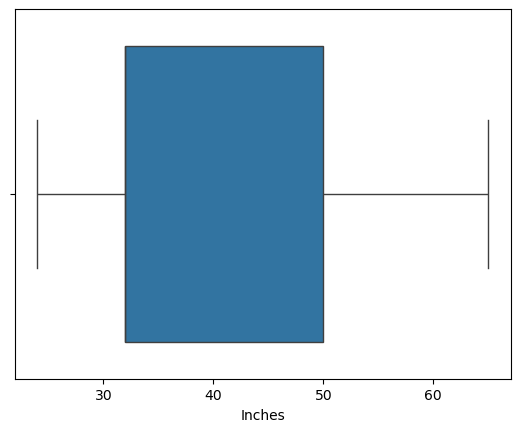

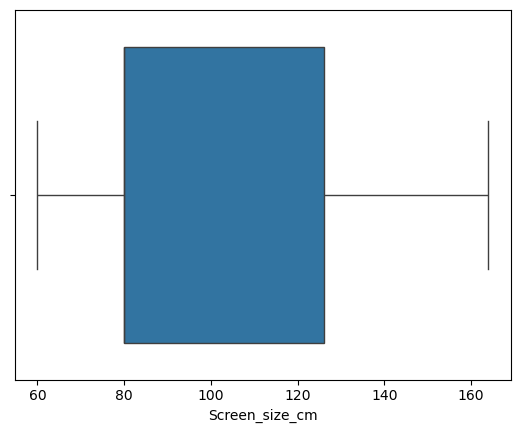

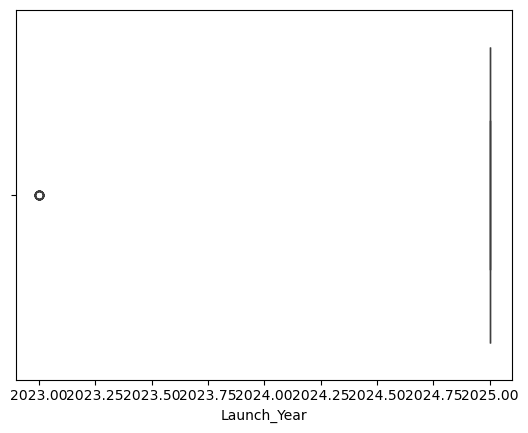

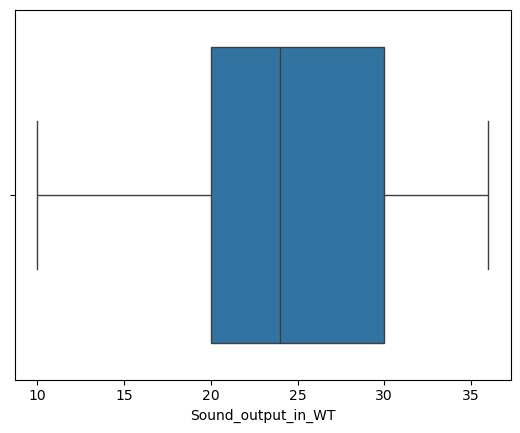

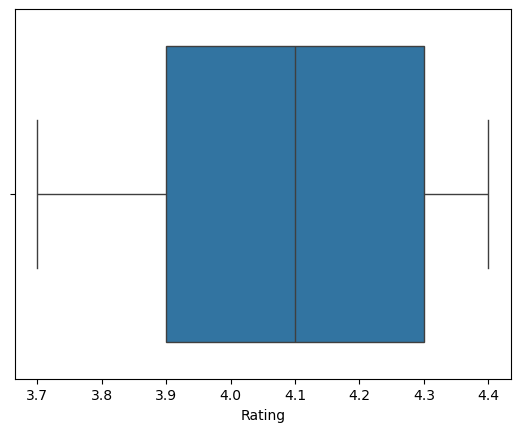

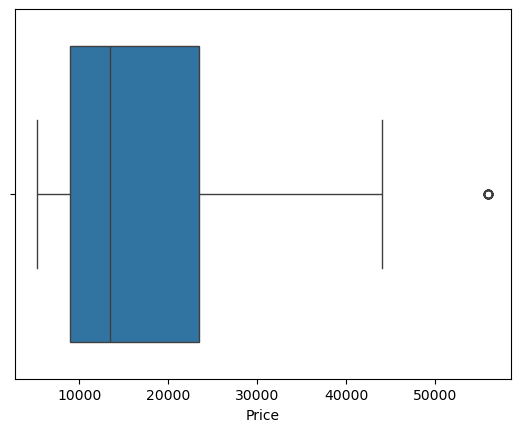

In [134]:
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings("ignore")
for i in df.select_dtypes(include="number").columns:
    sns.boxplot(data=df,x=i)
    plt.show()

#### Here i choose to not treat the otliers as the years and price mentioned in the data frame are according to the product  release into the market.

# Converting Data Types

In [135]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 552 entries, 0 to 575
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   Brand               552 non-null    object 
 1   Inches              552 non-null    int64  
 2   Screen_size_cm      552 non-null    int64  
 3   Launch_Year         552 non-null    int64  
 4   Sound_output_in_WT  552 non-null    int64  
 5   Screen_type         552 non-null    object 
 6   Rating              552 non-null    float64
 7   Order_ID            552 non-null    object 
 8   Price               552 non-null    int64  
 9   Quality             552 non-null    object 
dtypes: float64(1), int64(5), object(4)
memory usage: 47.4+ KB


### Here Data types are according to their column types

# Observations🔍

💡 Here, dataset contained 576 rows and 10 columns. 
There are no null values,special characters,
incorrect format of the data.There are some outliers but I choose not to treat the outliers as they are according to the market release and brand values.




# Exploratory Data Analysis 📊

**Categorical**: Brand , Screen_type, Quality

 **Numerical**: Inches, Screen_size_cm, Sound_output_in_WT, Order_ID, Price,Launch_Year

In [57]:
import warnings
warnings.filterwarnings("ignore") 

# ✦✦✦ UNIVARIATE ANALYSIS ✦✦✦

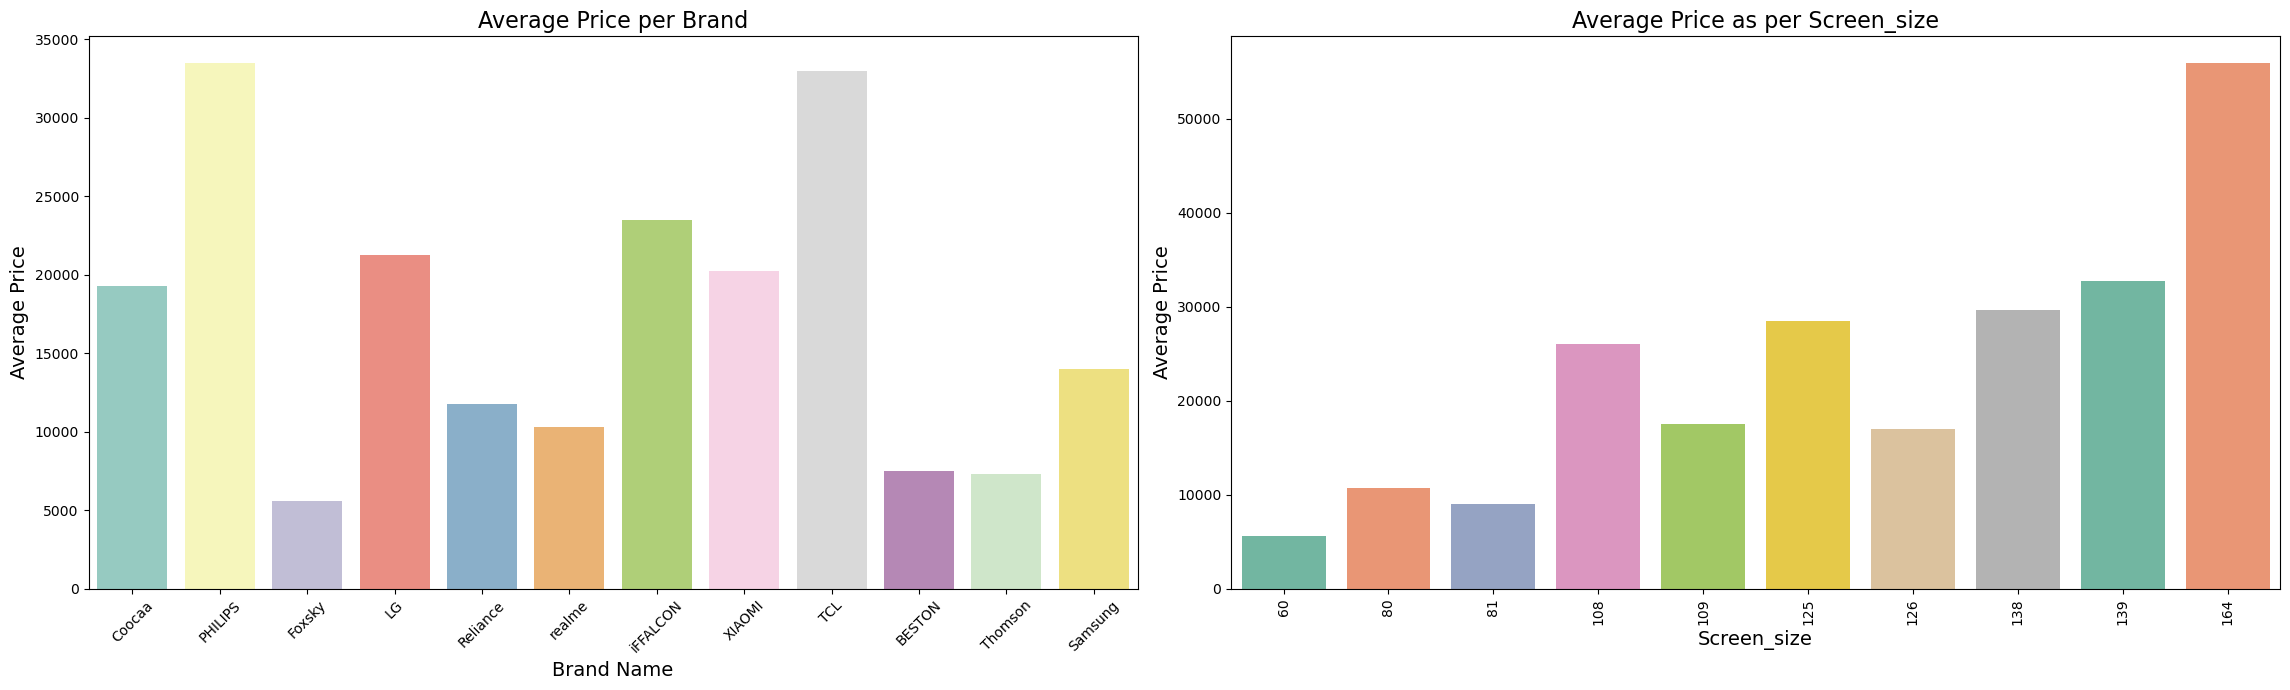

In [162]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.figure(figsize=(23, 7))

# 1️⃣ Bar Plot – Average Price per Brand
plt.subplot(1, 2, 1)
sns.barplot(
    data=df, 
    x='Brand', 
    y='Price', 
    palette="Set3", 
    estimator=np.mean,
    ci=None
)
plt.title("Average Price per Brand", fontsize=16)
plt.xlabel("Brand Name", fontsize=14)
plt.ylabel("Average Price", fontsize=14)
plt.xticks(rotation=45)

# 2️⃣ Bar Plot – Average Price per Model
plt.subplot(1, 2, 2)
sns.barplot(
    data=df, 
    x='Screen_size_cm', 
    y='Price', 
    palette="Set2", 
    estimator=np.mean,
    ci=None
)
plt.title("Average Price as per Screen_size", fontsize=16)
plt.xlabel("Screen_size", fontsize=14)
plt.ylabel("Average Price", fontsize=14)
plt.xticks(rotation=90)

plt.tight_layout()
plt.show()


#### Observations.
1.For the brands like Blueprint,TCL,Samsung and PHILIPS has higher prices and other brands has average prices.The brands like Foxsky,Thomson has verylow prices.

2.The more the screen size the higher the prices.


# 🟧 2. Count Plot

A count plot automatically counts how many times each category appears in the dataset.

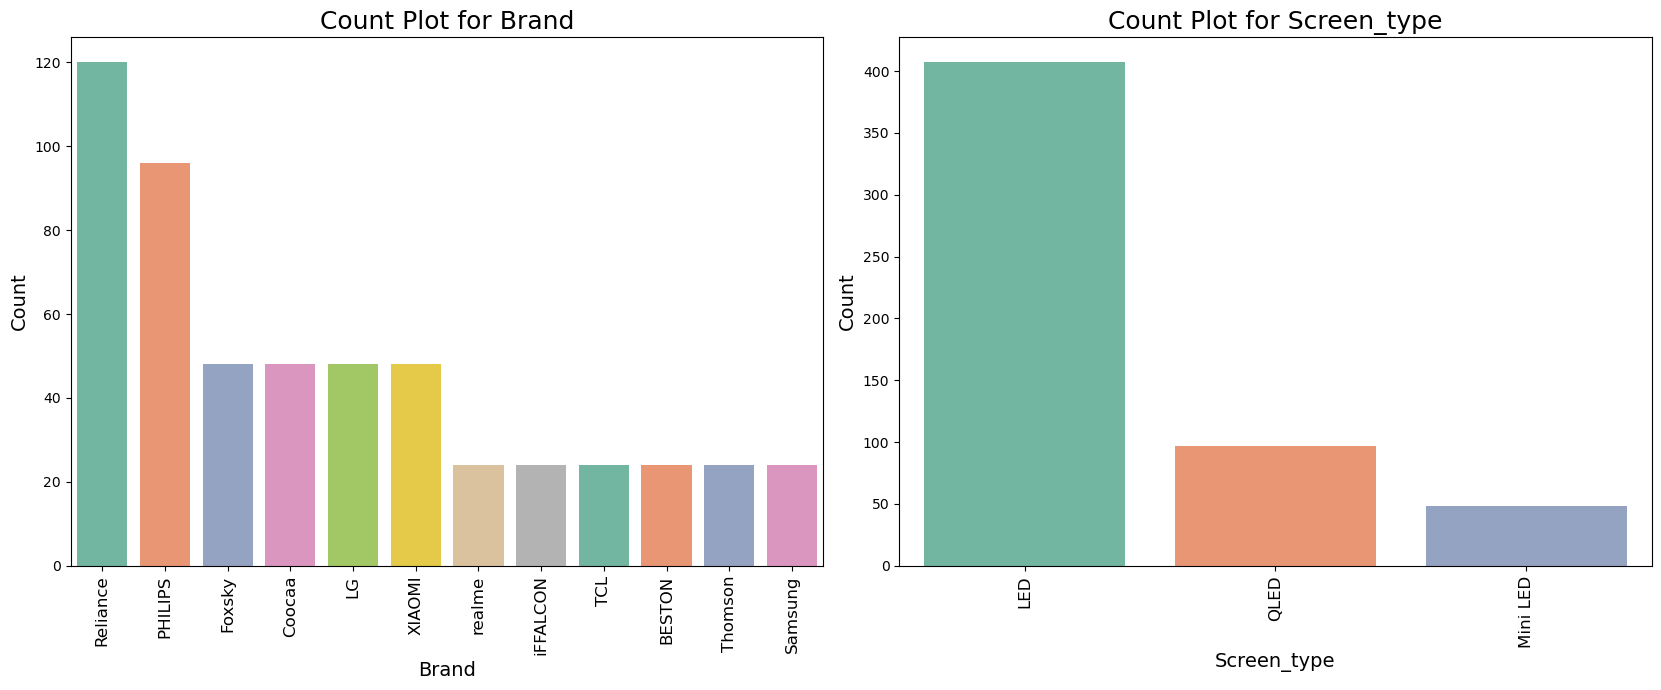

In [164]:
categorical_cols = [ 'Brand', 'Screen_type']
plt.figure(figsize=(25, 7))

for i, col in enumerate(categorical_cols, 1):
    
    plt.subplot(1, 3, i)
    sns.countplot(data=df,x=col, order=df[col].value_counts().index ,palette="Set2")
    
    plt.title(f'Count Plot for {col}', fontsize=18)
    plt.xticks(rotation=90, fontsize=12)
    plt.ylabel("Count", fontsize=14)
    plt.xlabel(col, fontsize=14)

plt.tight_layout()
plt.show()

#### Observations:
1.Most Telivisions in the dataset come from Foxsky, philips, xiaomi, and VW, showing they dominate the market.
Samsung,LG and Iffalcon have a moderate number of listings.
Many other brands appear only a few times, indicating they are less popular or rarely listed.

# ⭐ Numerical Data

# 🟪1. Histogram Plot

A histogram is a plot that shows how frequently different ranges of numerical values occur in a dataset.

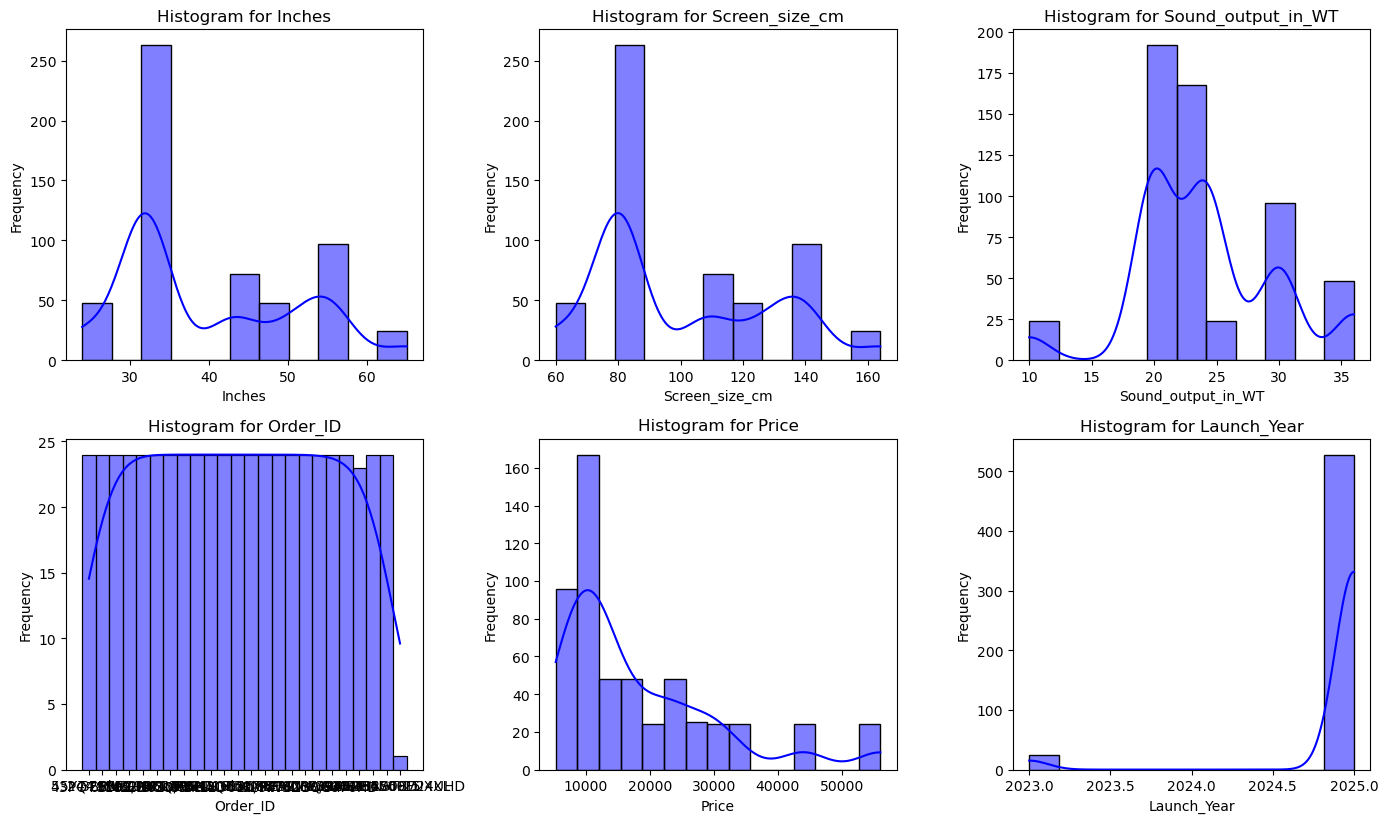

In [155]:
numerical_cols = ['Inches', 'Screen_size_cm', 'Sound_output_in_WT', 'Order_ID', 'Price','Launch_Year']

# Set the figure size

plt.figure(figsize=(14, 12))

# Create histogram plots for each numerical column
# KDE is added to visualize the distribution
  
for i, col in enumerate(numerical_cols, 1):
    plt.subplot(3, 3, i)  
    sns.histplot(data=df, x=col, kde=True, color='blue')  
    plt.title(f'Histogram for {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')

# Adjust layout

plt.tight_layout()
plt.show()

#### Observations:
Here, mostly prefered screen size varies betweenis 100-140 ,sound output is in between20-30WTfor the most TV's the price ranges between 20000-40000 and most of the TV's launched in the year 2025.

# 🔷 2. Violin Plot

💡A violin plot is a chart that displays the distribution of a numerical variable using a combination of a box plot and a density curve.

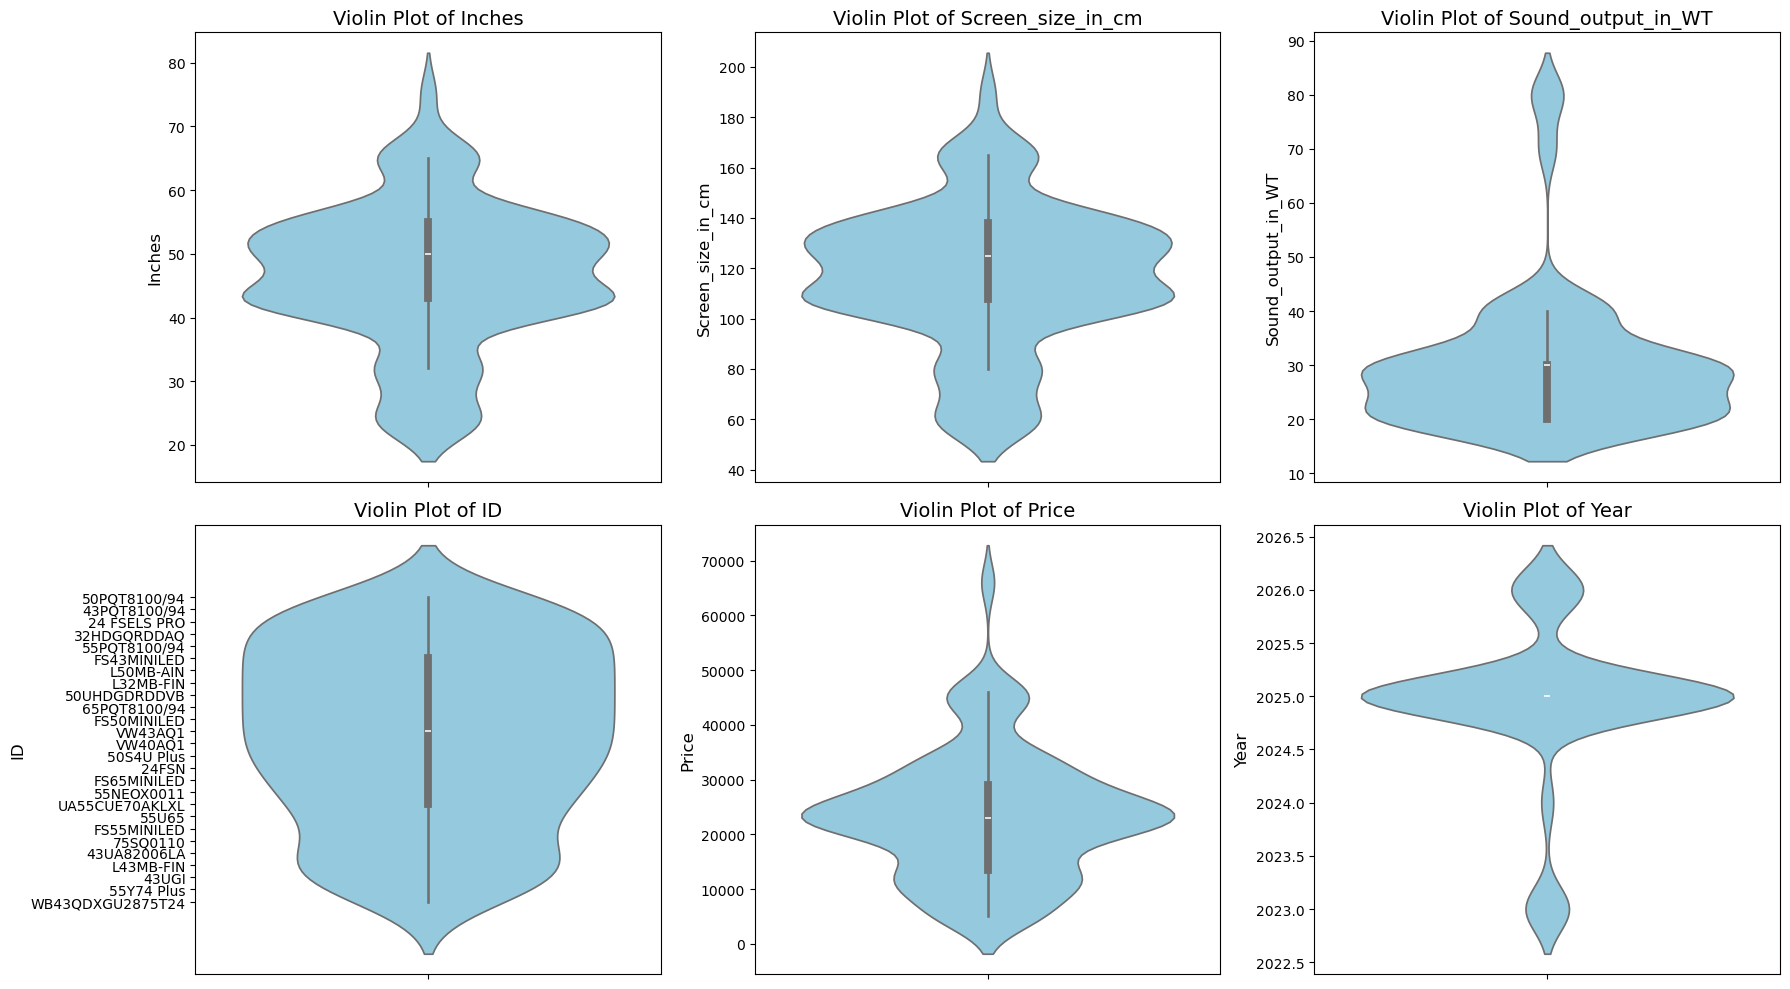

In [61]:
plt.figure(figsize=(18, 10))

for i, col in enumerate(numerical_cols, 1):
    plt.subplot(2, 3, i)  # 2 rows, 3 columns grid
    sns.violinplot(data=df, y=col, color="skyblue")
    plt.title(f'Violin Plot of {col}', fontsize=14)
    plt.ylabel(col, fontsize=12)

plt.tight_layout()
plt.show()

#### Observations:
It Shows how each numeric feature is spread and concentrated.

Inches, and screen size have clear central clusters, while sound output and year has  has a tight peak.


# Pie chart

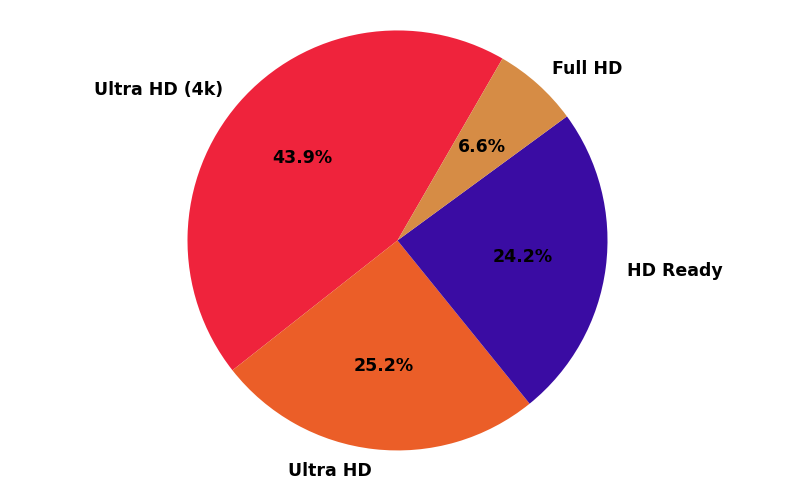

In [50]:
labels = 'Ultra HD (4k)', ' Ultra HD', 'HD Ready', 'Full HD '
sizes = [399,229,220,60]
fig, ax = plt.subplots(figsize=(10,6))
fig.set_facecolor('white')
ax.pie(sizes, labels=labels, colors=["#EF233C","#eb5e28","#3a0ca3","#d68c45","#00bbf9"],autopct='%1.1f%%', startangle=60,textprops={'color':'black','weight':'bold','fontsize':12.5})
ax.axis('equal')
plt.show()

#### Observation:
Ultra HD LED TV seems to be in greater demand as more than 40% of the products categorized as 'Television' on the website are of this type.

# ✦✦✦ BIVARIATE ANALYSIS ✦✦✦

Bivariate analysis examines the relationship between two variables to understand how one affects or is associated with the other

# ✨Categorical vs Categorical

# **✦1. Grouped bar plot**

A grouped bar plot is a bar chart that compares two categorical variables by placing multiple bars side-by-side within each category to show their counts or values.

<Figure size 1600x800 with 0 Axes>

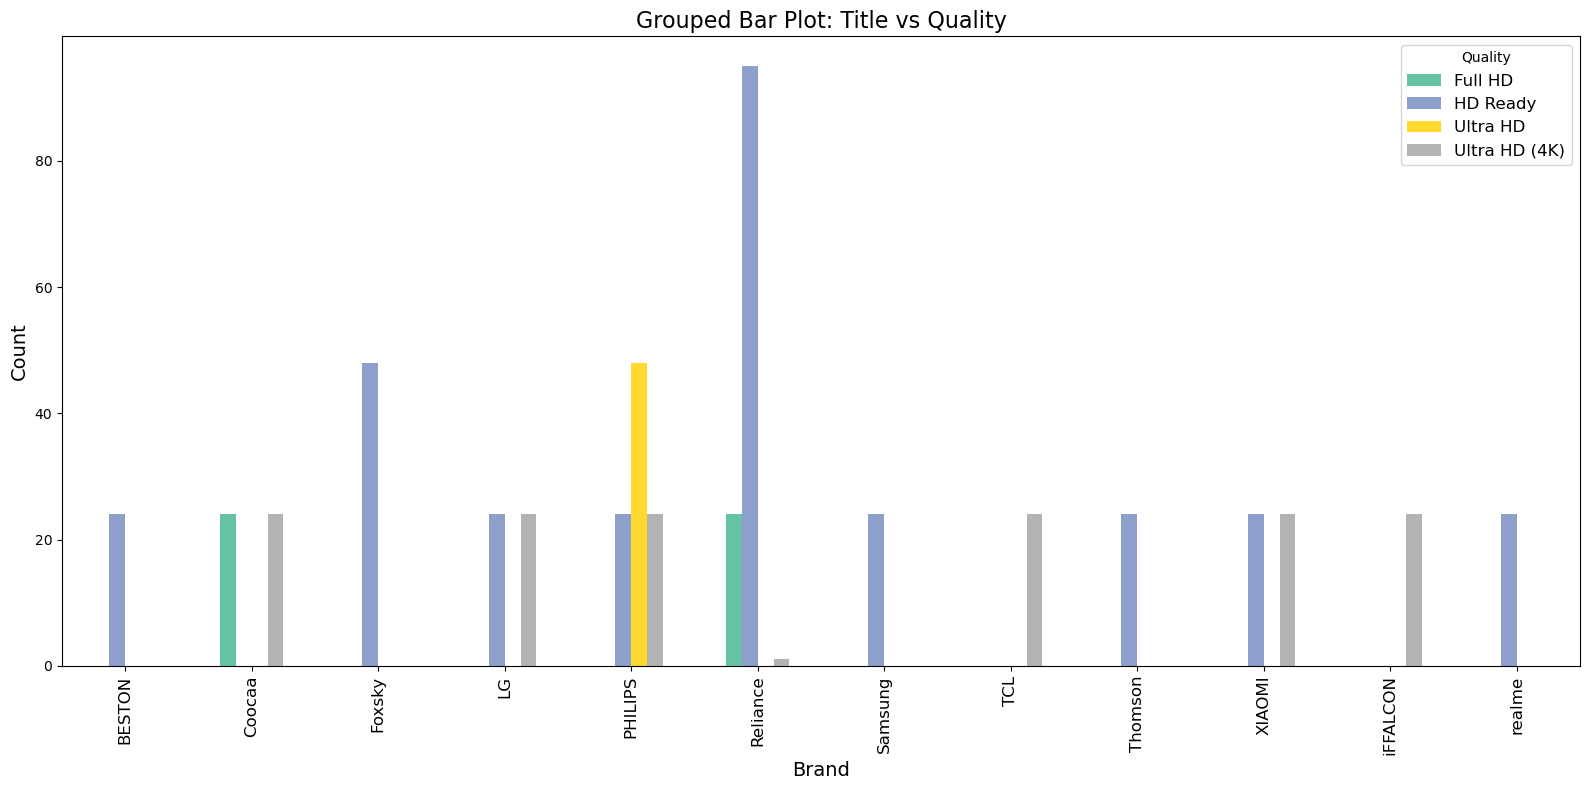

In [156]:
# Grouped Bar Plot (Brand vs Operating System)
grouped_data = df.groupby(['Brand', 'Quality']).size().unstack().fillna(0)

plt.figure(figsize=(16, 8))
grouped_data.plot(kind='bar', figsize=(16, 8), colormap='Set2')

plt.title('Grouped Bar Plot: Title vs Quality', fontsize=16)
plt.ylabel('Count', fontsize=14)
plt.xlabel('Brand', fontsize=14)
plt.xticks(rotation=90, fontsize=12)
plt.legend(title='Quality', fontsize=12)
plt.tight_layout()
plt.show()

•The bar plot shows the count of TVs 
by brand and resolution.

•Reliance,Foxsky has the highest number of TVs, 
mostly with HD ready (4k) resolution.

•Foxsky has the second highest number of TVs, 
 with ultra HD  resolution.
 Very less brand  TVs spread between Full HD.
 
•ultra HD (4k) is the most common 
resolution across brands.

# ✦2. Crosstab Heatmap

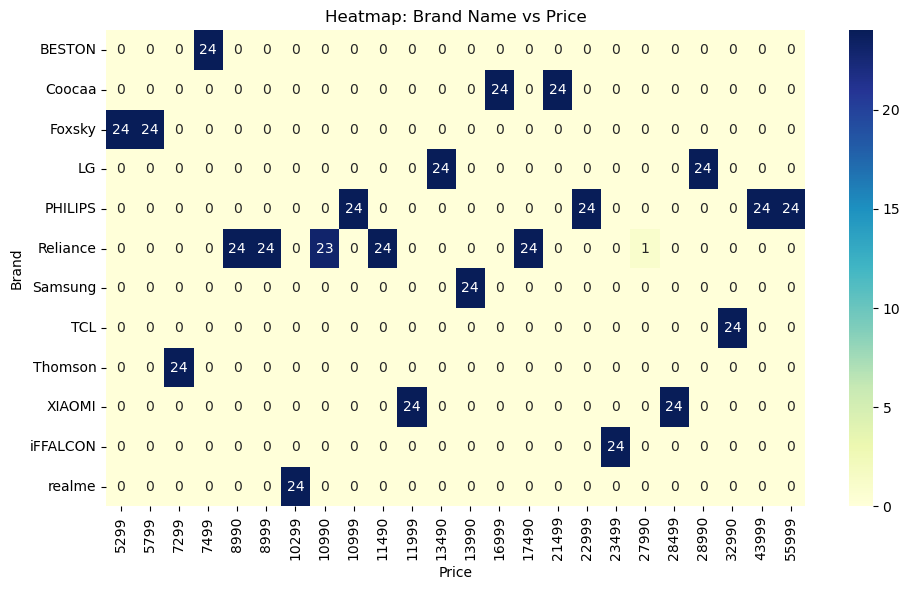

In [145]:
# Create a crosstab
crosstab_data = pd.crosstab(df['Brand'], df['Price'])

# Plot heatmap
plt.figure(figsize=(10, 6))
sns.heatmap(crosstab_data, annot=True, cmap='YlGnBu', fmt='g')
plt.title('Heatmap: Brand Name vs Price')
plt.ylabel('Brand')
plt.xlabel('Price')
plt.tight_layout()
plt.show()


Here the price varies based on the Brand.Every brand falls under its unique price rating.

# ✨Continuous vs Continuous

Compares the relationship between two numeric variables to see how they change together.

# ✦1.Scatter Plot

A scatter plot visualizes the relationship between two numerical variables by placing dots on a graph.

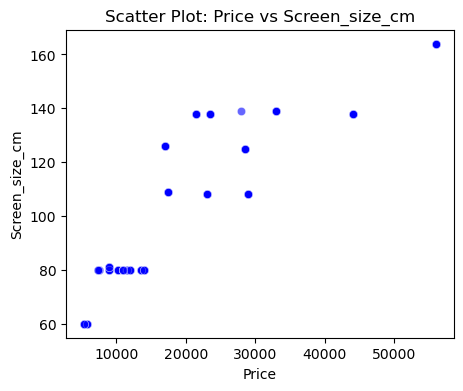

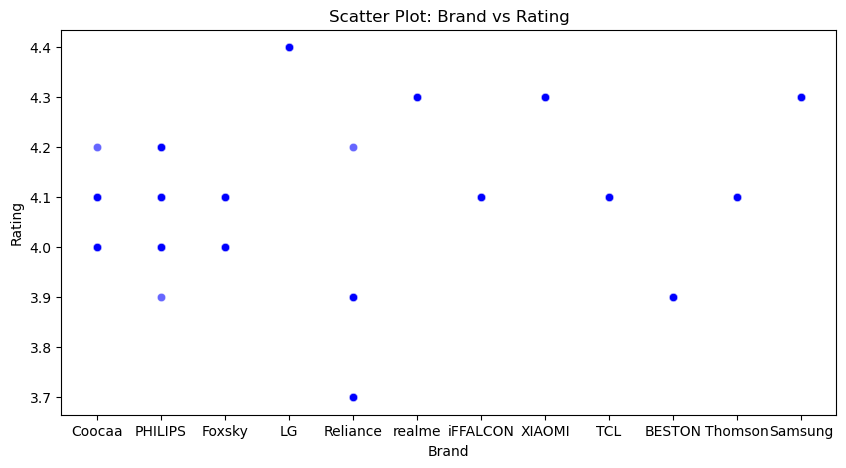

In [167]:
plt.figure(figsize=(5,4))
sns.scatterplot(data=df, x='Price', y='Screen_size_cm', color='blue', alpha=0.6)
plt.title("Scatter Plot: Price vs Screen_size_cm")
#plt.xticks(rotation=5)

plt.show()
#2)
plt.figure(figsize=(10,5))
sns.scatterplot(data=df, x='Brand', y='Rating', color='blue', alpha=0.6)
plt.title("Scatter Plot: Brand vs Rating")
#plt.xticks(rotation=5)

plt.show()

1.Here, we can see more the screen size high the price for tvs.Hence price for the TV is depends on screen size.

2.Brands like LG,realme,Xiome,Samsumg has higher ratings and other brands has average ratings.


# ✨Numerical vs Categorical

# ✦1.Box Plot

A box plot is a graphical summary of a numerical feature that shows its median, spread, and outliers in a single visual.

Index(['Brand', 'Inches', 'Screen_size_cm', 'Launch_Year',
       'Sound_output_in_WT', 'Screen_type', 'Rating', 'Order_ID', 'Price',
       'Quality'],
      dtype='object')


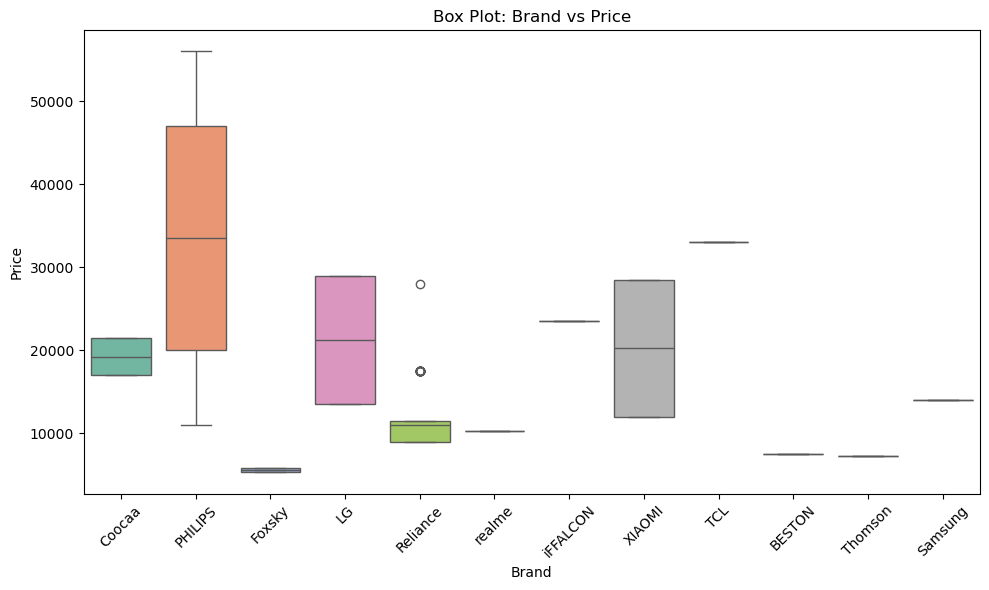

In [152]:
# Check columns
print(df.columns)

# Convert price to numeric
df['Price'] = pd.to_numeric(df['Price'], errors='coerce')

# Drop missing values
df = df.dropna(subset=['Brand', 'Price'])

plt.figure(figsize=(10,6))
sns.boxplot(data=df, x='Brand', y='Price', palette='Set2')
plt.title("Box Plot: Brand vs Price")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Shows price variation across brands ,
sbrands like PHILIPS and LG and XIAOMI have higher median prices.
Common brands like PHILIPS, FOXSKY appear most frequently.

# Conclusion

Most popular TVs are priced between ₹20,000 to ₹60,000. 
• Mid-sized TVs (32-40 inches) receive higher ratings than larger TVs.

• Ultra HD  TVs are more common and prefered by most of the people,Where Full HD and HD ready are rearely preferd. 
 
• Brands like LG,realme,Xiome,Samsumg has higher ratings and other brands has average ratings.

• TVs with higher ratings attract more reviews, indicating a positive correlation between 
popularity and feedback.

• Best value TVs are mid-sized, affordable Ultra HD models with Ultra HD resolution.